# Data Wrangling with Spark

This is the code used in the previous screencast. Run each code cell to understand what the code does and how it works.

These first three cells import libraries, instantiate a SparkSession, and then read in the data set

In [ ]:
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import desc
from pyspark.sql.functions import asc
from pyspark.sql.functions import sum as Fsum

import datetime

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession \
    .builder \
    .appName("Wrangling Data") \
    .master("local[*]") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/18 17:30:04 WARN Utils: Your hostname, Jeremy-Ubuntu, resolves to a loopback address: 127.0.1.1; using 192.168.150.230 instead (on interface wlo1)
26/02/18 17:30:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/18 17:30:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/18 17:30:09 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
path = "data/sparkify_log_small.json"
user_log = spark.read.json(path)

# Data Exploration 

The next cells explore the data set.

In [4]:
user_log.take(5)

[Row(artist='Showaddywaddy', auth='Logged In', firstName='Kenneth', gender='M', itemInSession=112, lastName='Matthews', length=232.93342, level='paid', location='Charlotte-Concord-Gastonia, NC-SC', method='PUT', page='NextSong', registration=1509380319284, sessionId=5132, song='Christmas Tears Will Fall', status=200, ts=1513720872284, userAgent='"Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/36.0.1985.125 Safari/537.36"', userId='1046'),
 Row(artist='Lily Allen', auth='Logged In', firstName='Elizabeth', gender='F', itemInSession=7, lastName='Chase', length=195.23873, level='free', location='Shreveport-Bossier City, LA', method='PUT', page='NextSong', registration=1512718541284, sessionId=5027, song='Cheryl Tweedy', status=200, ts=1513720878284, userAgent='"Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/36.0.1985.143 Safari/537.36"', userId='1000'),
 Row(artist='Cobra Starship Featuring Leighton Meester', auth='Logged In', firstNa

In [5]:
user_log.printSchema()

root
 |-- artist: string (nullable = true)
 |-- auth: string (nullable = true)
 |-- firstName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- itemInSession: long (nullable = true)
 |-- lastName: string (nullable = true)
 |-- length: double (nullable = true)
 |-- level: string (nullable = true)
 |-- location: string (nullable = true)
 |-- method: string (nullable = true)
 |-- page: string (nullable = true)
 |-- registration: long (nullable = true)
 |-- sessionId: long (nullable = true)
 |-- song: string (nullable = true)
 |-- status: long (nullable = true)
 |-- ts: long (nullable = true)
 |-- userAgent: string (nullable = true)
 |-- userId: string (nullable = true)



In [7]:
user_log.show(n=5)

+--------------------+---------+---------+------+-------------+---------+---------+-----+--------------------+------+--------+-------------+---------+--------------------+------+-------------+--------------------+------+
|              artist|     auth|firstName|gender|itemInSession| lastName|   length|level|            location|method|    page| registration|sessionId|                song|status|           ts|           userAgent|userId|
+--------------------+---------+---------+------+-------------+---------+---------+-----+--------------------+------+--------+-------------+---------+--------------------+------+-------------+--------------------+------+
|       Showaddywaddy|Logged In|  Kenneth|     M|          112| Matthews|232.93342| paid|Charlotte-Concord...|   PUT|NextSong|1509380319284|     5132|Christmas Tears W...|   200|1513720872284|"Mozilla/5.0 (Win...|  1046|
|          Lily Allen|Logged In|Elizabeth|     F|            7|    Chase|195.23873| free|Shreveport-Bossie...|   PUT

In [8]:
user_log.describe().show()

26/02/18 23:45:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+----------+---------+------+------------------+--------+-----------------+-----+------------+------+-------+--------------------+------------------+--------+-----------------+-------------------+--------------------+------------------+
|summary|           artist|      auth|firstName|gender|     itemInSession|lastName|           length|level|    location|method|   page|        registration|         sessionId|    song|           status|                 ts|           userAgent|            userId|
+-------+-----------------+----------+---------+------+------------------+--------+-----------------+-----+------------+------+-------+--------------------+------------------+--------+-----------------+-------------------+--------------------+------------------+
|  count|             8347|     10000|     9664|  9664|             10000|    9664|             8347|10000|        9664| 10000|  10000|                9664|             10000|    8347|            10000|         

In [9]:
user_log.describe("artist").show()

+-------+-----------------+
|summary|           artist|
+-------+-----------------+
|  count|             8347|
|   mean|            461.0|
| stddev|            300.0|
|    min|              !!!|
|    max|ÃÂlafur Arnalds|
+-------+-----------------+



In [10]:
user_log.describe("sessionId").show()

+-------+------------------+
|summary|         sessionId|
+-------+------------------+
|  count|             10000|
|   mean|         4436.7511|
| stddev|2043.1281541827561|
|    min|                 9|
|    max|              7144|
+-------+------------------+



In [11]:
user_log.count()

10000

In [12]:
user_log.select("page").dropDuplicates().sort("page").show()

+----------------+
|            page|
+----------------+
|           About|
|       Downgrade|
|           Error|
|            Help|
|            Home|
|           Login|
|          Logout|
|        NextSong|
|   Save Settings|
|        Settings|
|Submit Downgrade|
|  Submit Upgrade|
|         Upgrade|
+----------------+



In [ ]:
user_log.select(["userId", "firstname", "page", "song"]) \
    .where(user_log.userId == "1046").collect()    # The output returned by .collect() and .take() is a list different to .show() in the next cells

[Row(userId='1046', firstname='Kenneth', page='NextSong', song='Christmas Tears Will Fall'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Be Wary Of A Woman'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Public Enemy No.1'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Reign Of The Tyrants'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Father And Son'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='No. 5'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Seventeen'),
 Row(userId='1046', firstname='Kenneth', page='Home', song=None),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='War on war'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Killermont Street'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Black & Blue'),
 Row(userId='1046', firstname='Kenneth', page='Logout', song=None),
 Row(userId='1046', firstname='Kenneth'

In [ ]:
user_log.select(["userId", "firstname", "page", "song"]) \
    .where(user_log.userId == "1046").show()     # .show() returns 20 rows of a table by default without setting the argument n, n: int = 20

+------+---------+--------+--------------------+
|userId|firstname|    page|                song|
+------+---------+--------+--------------------+
|  1046|  Kenneth|NextSong|Christmas Tears W...|
|  1046|  Kenneth|NextSong|  Be Wary Of A Woman|
|  1046|  Kenneth|NextSong|   Public Enemy No.1|
|  1046|  Kenneth|NextSong|Reign Of The Tyrants|
|  1046|  Kenneth|NextSong|      Father And Son|
|  1046|  Kenneth|NextSong|               No. 5|
|  1046|  Kenneth|NextSong|           Seventeen|
|  1046|  Kenneth|    Home|                NULL|
|  1046|  Kenneth|NextSong|          War on war|
|  1046|  Kenneth|NextSong|   Killermont Street|
|  1046|  Kenneth|NextSong|        Black & Blue|
|  1046|  Kenneth|  Logout|                NULL|
|  1046|  Kenneth|    Home|                NULL|
|  1046|  Kenneth|NextSong|     Heads Will Roll|
|  1046|  Kenneth|NextSong|Bleed It Out [Liv...|
|  1046|  Kenneth|NextSong|              Clocks|
|  1046|  Kenneth|NextSong|           Love Rain|
|  1046|  Kenneth|Ne

In [18]:
user_log.select(["userId", "firstname", "page", "song"]) \
    .where(user_log.userId == "1046").take(num=20)

[Row(userId='1046', firstname='Kenneth', page='NextSong', song='Christmas Tears Will Fall'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Be Wary Of A Woman'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Public Enemy No.1'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Reign Of The Tyrants'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Father And Son'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='No. 5'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Seventeen'),
 Row(userId='1046', firstname='Kenneth', page='Home', song=None),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='War on war'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Killermont Street'),
 Row(userId='1046', firstname='Kenneth', page='NextSong', song='Black & Blue'),
 Row(userId='1046', firstname='Kenneth', page='Logout', song=None),
 Row(userId='1046', firstname='Kenneth'

In [22]:
print("collect method", type(user_log.select(["userId", "firstname", "page", "song"]) \
    .where(user_log.userId == "1046").collect()))
print("show method", type(user_log.select(["userId", "firstname", "page", "song"]) \
    .where(user_log.userId == "1046").show()))
print("take method", type(user_log.select(["userId", "firstname", "page", "song"]) \
    .where(user_log.userId == "1046").take(num=20)))

collect method <class 'list'>
+------+---------+--------+--------------------+
|userId|firstname|    page|                song|
+------+---------+--------+--------------------+
|  1046|  Kenneth|NextSong|Christmas Tears W...|
|  1046|  Kenneth|NextSong|  Be Wary Of A Woman|
|  1046|  Kenneth|NextSong|   Public Enemy No.1|
|  1046|  Kenneth|NextSong|Reign Of The Tyrants|
|  1046|  Kenneth|NextSong|      Father And Son|
|  1046|  Kenneth|NextSong|               No. 5|
|  1046|  Kenneth|NextSong|           Seventeen|
|  1046|  Kenneth|    Home|                NULL|
|  1046|  Kenneth|NextSong|          War on war|
|  1046|  Kenneth|NextSong|   Killermont Street|
|  1046|  Kenneth|NextSong|        Black & Blue|
|  1046|  Kenneth|  Logout|                NULL|
|  1046|  Kenneth|    Home|                NULL|
|  1046|  Kenneth|NextSong|     Heads Will Roll|
|  1046|  Kenneth|NextSong|Bleed It Out [Liv...|
|  1046|  Kenneth|NextSong|              Clocks|
|  1046|  Kenneth|NextSong|           L

# Calculating Statistics by Hour

In [24]:
get_hour = udf(lambda x: datetime.datetime.fromtimestamp(x / 1000.0).hour)

In [ ]:
user_log = user_log \
    .withColumn(colName="hour", col=get_hour(user_log.ts))

In [26]:
user_log.head()

Row(artist='Showaddywaddy', auth='Logged In', firstName='Kenneth', gender='M', itemInSession=112, lastName='Matthews', length=232.93342, level='paid', location='Charlotte-Concord-Gastonia, NC-SC', method='PUT', page='NextSong', registration=1509380319284, sessionId=5132, song='Christmas Tears Will Fall', status=200, ts=1513720872284, userAgent='"Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/36.0.1985.125 Safari/537.36"', userId='1046', hour='1')

In [27]:
user_log.printSchema()

root
 |-- artist: string (nullable = true)
 |-- auth: string (nullable = true)
 |-- firstName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- itemInSession: long (nullable = true)
 |-- lastName: string (nullable = true)
 |-- length: double (nullable = true)
 |-- level: string (nullable = true)
 |-- location: string (nullable = true)
 |-- method: string (nullable = true)
 |-- page: string (nullable = true)
 |-- registration: long (nullable = true)
 |-- sessionId: long (nullable = true)
 |-- song: string (nullable = true)
 |-- status: long (nullable = true)
 |-- ts: long (nullable = true)
 |-- userAgent: string (nullable = true)
 |-- userId: string (nullable = true)
 |-- hour: string (nullable = true)



In [28]:
songs_in_hour = user_log \
    .filter(user_log.page == "NextSong") \
    .groupby(user_log.hour) \
    .count() \
    .orderBy(user_log.hour.cast("float"))

In [29]:
songs_in_hour.show()

+----+-----+
|hour|count|
+----+-----+
|   0|  248|
|   1|  369|
|   2|  375|
|   3|  456|
|   4|  454|
|   5|  382|
|   6|  302|
|   7|  352|
|   8|  276|
|   9|  348|
|  10|  358|
|  11|  375|
|  12|  249|
|  13|  216|
|  14|  228|
|  15|  251|
|  16|  339|
|  17|  462|
|  18|  479|
|  19|  484|
+----+-----+
only showing top 20 rows


In [30]:
songs_in_hour_pd = songs_in_hour.toPandas()
songs_in_hour_pd.hour = pd.to_numeric(songs_in_hour_pd.hour)

In [31]:
songs_in_hour_pd.head()

,hour,count
0,0,248
1,1,369
2,2,375
3,3,456
4,4,454


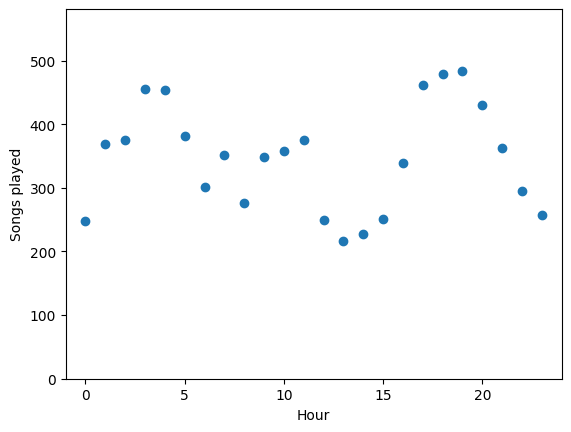

In [32]:
plt.scatter(songs_in_hour_pd["hour"], songs_in_hour_pd["count"])
plt.xlim(-1, 24);
plt.ylim(0, 1.2 * max(songs_in_hour_pd["count"]))
plt.xlabel("Hour")
plt.ylabel("Songs played");

# Drop Rows with Missing Values

As you'll see, it turns out there are no missing values in the userID or session columns. But there are userID values that are empty strings.

In [33]:
user_log_valid = user_log.dropna(how = "any", subset = ["userId", "sessionId"])

In [34]:
user_log_valid.count()

10000

In [35]:
user_log.select("userId").dropDuplicates().sort("userId").show()

+------+
|userId|
+------+
|      |
|    10|
|   100|
|  1000|
|  1003|
|  1005|
|  1006|
|  1017|
|  1019|
|  1020|
|  1022|
|  1025|
|  1030|
|  1035|
|  1037|
|   104|
|  1040|
|  1042|
|  1043|
|  1046|
+------+
only showing top 20 rows


In [36]:
user_log_valid = user_log_valid.filter(user_log_valid["userId"] != "")

In [37]:
user_log_valid.count()

9664

# Users Downgrade Their Accounts

Find when users downgrade their accounts and then flag those log entries. Then use a window function and cumulative sum to distinguish each user's data as either pre or post downgrade events.

In [38]:
user_log_valid.filter("page = 'Submit Downgrade'").show()

+------+---------+---------+------+-------------+--------+------+-----+--------------------+------+----------------+-------------+---------+----+------+-------------+--------------------+------+----+
|artist|     auth|firstName|gender|itemInSession|lastName|length|level|            location|method|            page| registration|sessionId|song|status|           ts|           userAgent|userId|hour|
+------+---------+---------+------+-------------+--------+------+-----+--------------------+------+----------------+-------------+---------+----+------+-------------+--------------------+------+----+
|  NULL|Logged In|    Kelly|     F|           24|  Newton|  NULL| paid|Houston-The Woodl...|   PUT|Submit Downgrade|1513283366284|     5931|NULL|   307|1513768454284|Mozilla/5.0 (Wind...|  1138|  14|
+------+---------+---------+------+-------------+--------+------+-----+--------------------+------+----------------+-------------+---------+----+------+-------------+--------------------+------+----+


In [39]:
user_log_valid.filter(user_log_valid.page == 'Submit Downgrade').show()

+------+---------+---------+------+-------------+--------+------+-----+--------------------+------+----------------+-------------+---------+----+------+-------------+--------------------+------+----+
|artist|     auth|firstName|gender|itemInSession|lastName|length|level|            location|method|            page| registration|sessionId|song|status|           ts|           userAgent|userId|hour|
+------+---------+---------+------+-------------+--------+------+-----+--------------------+------+----------------+-------------+---------+----+------+-------------+--------------------+------+----+
|  NULL|Logged In|    Kelly|     F|           24|  Newton|  NULL| paid|Houston-The Woodl...|   PUT|Submit Downgrade|1513283366284|     5931|NULL|   307|1513768454284|Mozilla/5.0 (Wind...|  1138|  14|
+------+---------+---------+------+-------------+--------+------+-----+--------------------+------+----------------+-------------+---------+----+------+-------------+--------------------+------+----+


In [40]:
user_log.select(["userId", "firstname", "page", "level", "song"]).where(user_log.userId == "1138").collect()

[Row(userId='1138', firstname='Kelly', page='Home', level='paid', song=None),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Everybody Everybody'),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Gears'),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Use Somebody'),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Love Of My Life (1993 Digital Remaster)'),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Down In The Valley Woe'),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Treat Her Like A Lady'),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song="Everybody Thinks You're An Angel"),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Fourteen Wives'),
 Row(userId='1138', firstname='Kelly', page='NextSong', level='paid', song='Love On The Rocks'),
 Row(userId='1138', f

In [41]:
user_log.select("page").dropDuplicates().count()

13

In [42]:
user_log.select("page").dropDuplicates().show()

+----------------+
|            page|
+----------------+
|Submit Downgrade|
|            Home|
|       Downgrade|
|          Logout|
|   Save Settings|
|           About|
|        Settings|
|           Login|
|        NextSong|
|            Help|
|         Upgrade|
|           Error|
|  Submit Upgrade|
+----------------+



In [43]:
flag_downgrade_event = udf(lambda x: 1 if x == "Submit Downgrade" else 0, IntegerType())

In [44]:
flag_downgrade_event

<function __main__.<lambda>(x)>

In [45]:
user_log_valid = user_log_valid.withColumn("downgraded", flag_downgrade_event("page"))

In [46]:
user_log_valid.printSchema()

root
 |-- artist: string (nullable = true)
 |-- auth: string (nullable = true)
 |-- firstName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- itemInSession: long (nullable = true)
 |-- lastName: string (nullable = true)
 |-- length: double (nullable = true)
 |-- level: string (nullable = true)
 |-- location: string (nullable = true)
 |-- method: string (nullable = true)
 |-- page: string (nullable = true)
 |-- registration: long (nullable = true)
 |-- sessionId: long (nullable = true)
 |-- song: string (nullable = true)
 |-- status: long (nullable = true)
 |-- ts: long (nullable = true)
 |-- userAgent: string (nullable = true)
 |-- userId: string (nullable = true)
 |-- hour: string (nullable = true)
 |-- downgraded: integer (nullable = true)



In [47]:
user_log_valid.select("downgraded").dropDuplicates().show()

+----------+
|downgraded|
+----------+
|         1|
|         0|
+----------+



In [48]:
user_log_valid.head()

Row(artist='Showaddywaddy', auth='Logged In', firstName='Kenneth', gender='M', itemInSession=112, lastName='Matthews', length=232.93342, level='paid', location='Charlotte-Concord-Gastonia, NC-SC', method='PUT', page='NextSong', registration=1509380319284, sessionId=5132, song='Christmas Tears Will Fall', status=200, ts=1513720872284, userAgent='"Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/36.0.1985.125 Safari/537.36"', userId='1046', hour='1', downgraded=0)

In [ ]:
# ORDER BY userId RANGE BETWEEN UNBOUNDED PRECEDING AND 0 FOLLOWING ROW
windowval = Window.partitionBy("userId").orderBy(desc("ts")).rangeBetween(Window.unboundedPreceding, 0)

In [51]:
windowval

In [59]:
# ORDER BY date ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
window = Window.orderBy("ts").rowsBetween(Window.unboundedPreceding, Window.currentRow)
# PARTITION BY country ORDER BY date RANGE BETWEEN 3 PRECEDING AND 3 FOLLOWING
window = Window.orderBy(desc("ts")).partitionBy("phase").rangeBetween(-3, 3)

In [53]:
user_log_valid = user_log_valid.withColumn("phase", Fsum("downgraded").over(windowval))

In [54]:
user_log_valid.select(["userId", "firstname", "ts", "page", "level", "phase"]) \
    .where(user_log.userId == "1138").sort("ts").collect()

[Row(userId='1138', firstname='Kelly', ts=1513729066284, page='Home', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513729066284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513729313284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513729552284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513729783284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513730001284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513730263284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513730518284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513730768284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firstname='Kelly', ts=1513731182284, page='NextSong', level='paid', phase=1),
 Row(userId='1138', firs

In [57]:
valid_user_logs = (
    user_log_valid
    .select(["userId", "firstname", "ts", "page", "level", "phase"])
    .where(user_log_valid.userId == "1138")
    .sort("ts")
    .collect()
)

from pydantic import BaseModel
from typing import List

class UserLog(BaseModel):
    userId: int
    firstname: str
    ts: int
    page: str
    level: str
    phase: int

class UserLogList(BaseModel):
    user_logs: List[UserLog]

logs = []
for vul in valid_user_logs[:20]:
    logs.append(
        UserLog(
            userId=int(vul.userId),
            firstname=vul.firstname,
            ts=int(vul.ts),
            page=vul.page,
            level=vul.level,
            phase=int(vul.phase)
        )
    )

result = UserLogList(user_logs=logs)

print(result.model_dump())

{'user_logs': [{'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729066284, 'page': 'Home', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729066284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729313284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729552284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729783284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730001284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730263284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730518284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730768284, 'page': 'NextSong', 'level': 'paid', 'phase': 1},

In [58]:
valid_user_logs = (
    user_log_valid
    .select(["userId", "firstname", "ts", "page", "level", "phase"])
    .where(user_log_valid.userId == "1138")
    .sort("ts")
    .collect()
)

from pydantic import BaseModel
from typing import List

class UserLog(BaseModel):
    userId: int
    firstname: str
    ts: int
    page: str
    level: str
    phase: int

class UserLogList(BaseModel):
    user_logs: List[UserLog]

logs = []
for vul in valid_user_logs[:20]:
    logs = [
        UserLog(
            userId=int(v.userId),
            firstname=v.firstname,
            ts=int(v.ts),
            page=v.page,
            level=v.level,
            phase=int(v.phase)
        )
        for v in valid_user_logs[:20]
    ]

result = UserLogList(user_logs=logs)

print(result.model_dump())

{'user_logs': [{'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729066284, 'page': 'Home', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729066284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729313284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729552284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513729783284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730001284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730263284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730518284, 'page': 'NextSong', 'level': 'paid', 'phase': 1}, {'userId': 1138, 'firstname': 'Kelly', 'ts': 1513730768284, 'page': 'NextSong', 'level': 'paid', 'phase': 1},